## 0. Install dependencies

This notebook requires ``iqm-qubit-selector``. Run the cell below once per environment; re-running it is
harmless if the package is already installed.

In [ ]:
%pip install --quiet iqm-qubit-selector

# Qubit Selector: picking the right qubits for your circuit

On a real QPU, not all qubits are equal. Gate fidelities, readout fidelities and coherence times vary
across the chip and drift between calibrations. Running the same circuit on a different set of physical
qubits can change the quality of the result substantially.

``iqm-qubit-selector`` is a client-side package that picks an optimal qubit layout for a given quantum
circuit on IQM QPUs of crystal (square grid) topology, using the latest calibration data of the device.
The framework currently works with ``qiskit`` circuits.

**What this notebook covers:**

1. **Setup and authentication** - imports, IQM token, backend.
2. **Calibration data** - fetch the fidelities the selection is based on and visualize them.
3. **One API call to the best layout** - generate candidate layouts and rank them by cost.
4. **Inspecting the candidates** - the full list of layouts compatible with the circuit.
5. **Tuning the cost function** - readout fidelity or QNDness, CZ vs Clifford fidelity, more trials,
   excluding specific qubits.
6. **Live demo on hardware** - a GHZ state on a naive layout vs. the selected layout, compared with the
   Hellinger fidelity.

Throughout, remember: **the lower the cost, the better the layout**, and all qubit indices in layouts are
``qiskit`` indices.

## 1. Setup and authentication

In [1]:
import os

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import hellinger_fidelity
from qiskit.visualization import plot_histogram

from iqm.qiskit_iqm import IQMProvider
from iqm.qubit_selector.qiskit_utils import CircuitType, get_circuit, perform_backend_transpilation
from iqm.qubit_selector.qubit_selector import *

## Plotting helpers for this demo, defined in utils.py next to this notebook.
from utils import (
    apply_demo_style,
    plot_calibration_data,
    plot_cost_spread,
    plot_fidelity_comparison,
    plot_layout_comparison,
    plot_qpu_layout,
)

apply_demo_style()

/Users/aniketrath_travel/IEEE Demo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The token is read from the ``IQM_TOKEN`` environment variable. Setting it inside the notebook, as below, is
convenient but **not recommended**: it is easy to expose the token accidentally, for example when giving a
presentation or when committing the notebook to a shared repository. Prefer exporting it in your shell
before starting Jupyter.

In [2]:
import os

from dotenv import load_dotenv

load_dotenv()  # loads IQM_TOKEN from a local .env file into os.environ
token = os.getenv("IQM_TOKEN")
quantum_computer = "garnet"  # e.g. sapphire, ruby, ...
iqm_server_url = "https://resonance.iqm.tech/"  # provide your actual IQM server URL
os.environ["IQM_SERVER_URL"] = iqm_server_url
provider = IQMProvider(iqm_server_url, quantum_computer=quantum_computer)
backend = provider.get_backend()

print(f"Connected to {quantum_computer} with {backend.num_qubits} qubits.")

Connected to garnet with 20 qubits.


## 2. Calibration data: why the layout matters

``CalibrationDataManager`` fetches the calibration fidelities that the cost function is built on: two-qubit
gate fidelities (CZ and Clifford), single-qubit gate fidelities, readout fidelity and QNDness, and the
coherence times T1 and T2.

All plotting in this notebook comes from ``utils.py``, which sits next to the notebook and holds the shared
palette and plot style.

In [3]:
calibration_data = CalibrationDataManager().get_calibration_fidelities(backend)

print("Available calibration metrics:")
for key, values in calibration_data.items():
    print(f"  {key:<16} {len(values)} entries")

Available calibration metrics:
  CZ               60 entries
  CLIFFORD         60 entries
  1Q               20 entries
  readout          20 entries
  readout_qndness  20 entries
  t1               20 entries
  t2               20 entries


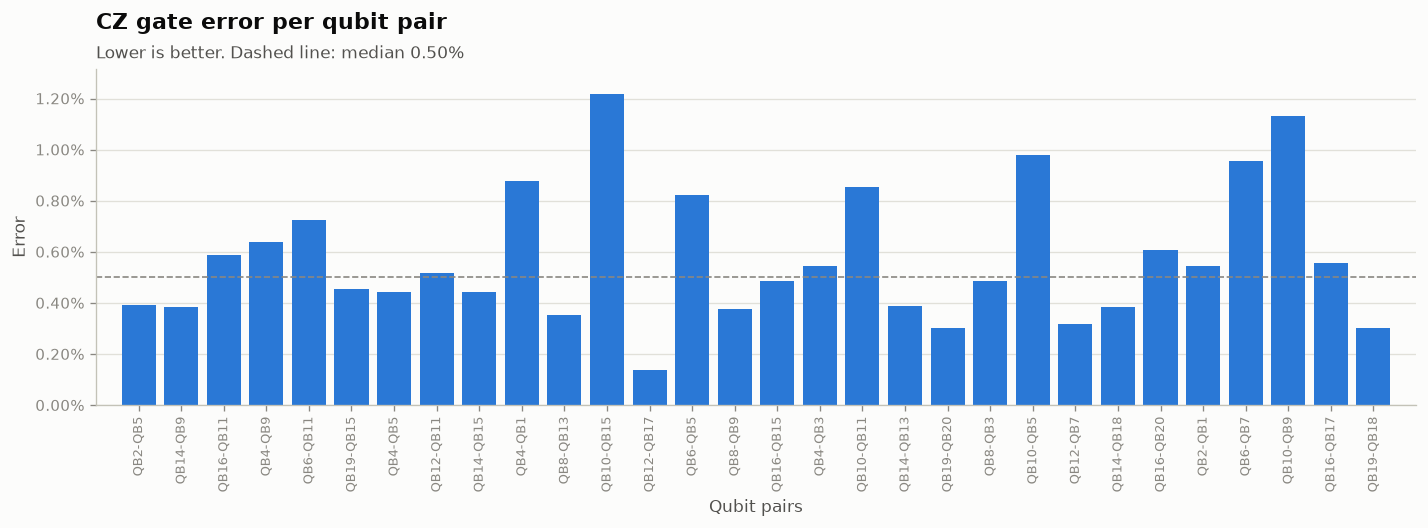

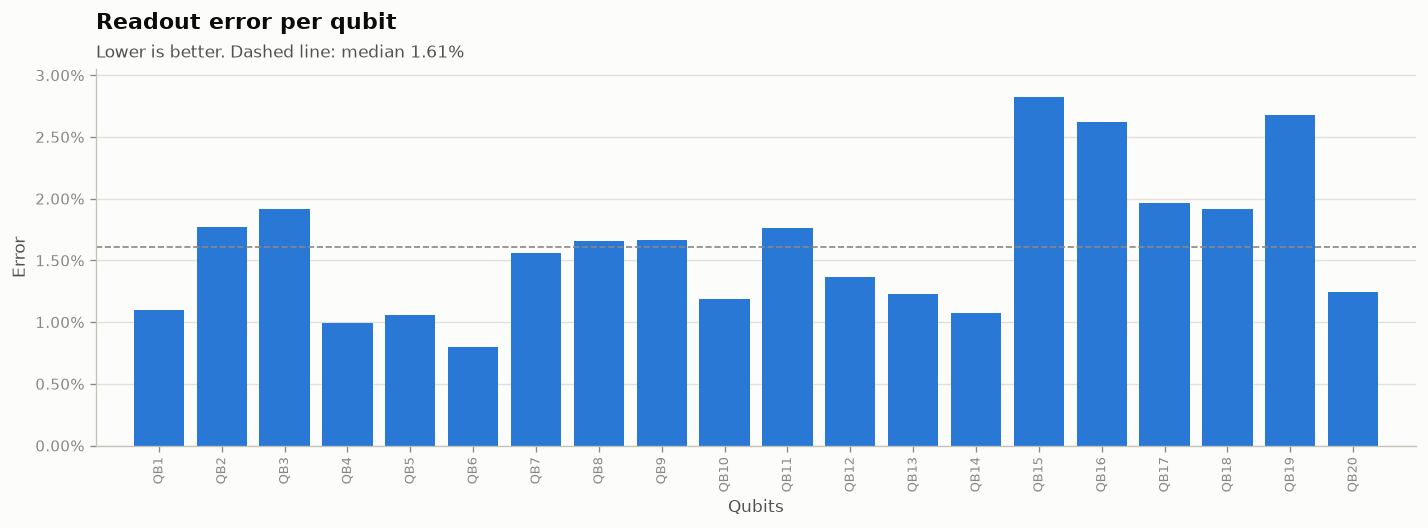

In [4]:
## The spread across the chip is exactly what the qubit selector exploits.
for key in [CalibrationType.CZ.value, CalibrationType.READOUT.value]:
    if key in calibration_data:
        plot_calibration_data(key, calibration_data[key])

## uncomment for all calibration metrics
# for k, v in calibration_data.items():
#     plot_calibration_data(k, v)

## 3. A single API call to get the best layout

``CostEvaluator`` generates the candidate layouts for the circuit and scores them against the calibration
data. ``get_top_layouts`` returns the layouts and their costs, sorted best first.

Note that the lower the value of the cost, the better the layout. The qubit indices in a layout are
``qiskit`` based; ``backend.index_to_qubit_name`` converts them to the physical qubit names.

In [5]:
nqubits = 10

## The GHZ circuit, built by hand. Plug in your own qiskit circuit of interest here.
qc_algo = QuantumCircuit(nqubits)
qc_algo.h(0)
for i in range(1, nqubits):
    qc_algo.cx(i - 1, i)
qc_algo.measure_all()

layouts, cost = CostEvaluator(backend=backend, quantum_circuit=qc_algo).get_top_layouts(num_layouts=50)

print("Top 10 qiskit layouts and their costs:")
for layout, c in zip(layouts[:10], cost[:10]):
    qubit_names = [backend.index_to_qubit_name(q) for q in layout]
    print(f"Layout: {layout}, Cost: {c * 100:.2f}%, Qubits: {qubit_names}")

Top 10 qiskit layouts and their costs:
Layout: [1, 3, 4, 7, 8, 12, 13, 17, 18, 19], Cost: 4.61%, Qubits: ['QB2', 'QB4', 'QB5', 'QB8', 'QB9', 'QB13', 'QB14', 'QB18', 'QB19', 'QB20']
Layout: [1, 2, 3, 4, 7, 12, 13, 17, 18, 19], Cost: 4.66%, Qubits: ['QB2', 'QB3', 'QB4', 'QB5', 'QB8', 'QB13', 'QB14', 'QB18', 'QB19', 'QB20']
Layout: [1, 2, 3, 4, 7, 8, 13, 17, 18, 19], Cost: 4.70%, Qubits: ['QB2', 'QB3', 'QB4', 'QB5', 'QB8', 'QB9', 'QB14', 'QB18', 'QB19', 'QB20']
Layout: [3, 4, 7, 8, 12, 13, 15, 17, 18, 19], Cost: 4.78%, Qubits: ['QB4', 'QB5', 'QB8', 'QB9', 'QB13', 'QB14', 'QB16', 'QB18', 'QB19', 'QB20']
Layout: [2, 3, 4, 7, 12, 13, 15, 17, 18, 19], Cost: 4.83%, Qubits: ['QB3', 'QB4', 'QB5', 'QB8', 'QB13', 'QB14', 'QB16', 'QB18', 'QB19', 'QB20']
Layout: [1, 3, 4, 7, 8, 12, 13, 14, 18, 19], Cost: 4.84%, Qubits: ['QB2', 'QB4', 'QB5', 'QB8', 'QB9', 'QB13', 'QB14', 'QB15', 'QB19', 'QB20']
Layout: [1, 3, 4, 7, 8, 12, 13, 14, 17, 18], Cost: 4.87%, Qubits: ['QB2', 'QB4', 'QB5', 'QB8', 'QB9', 'QB13

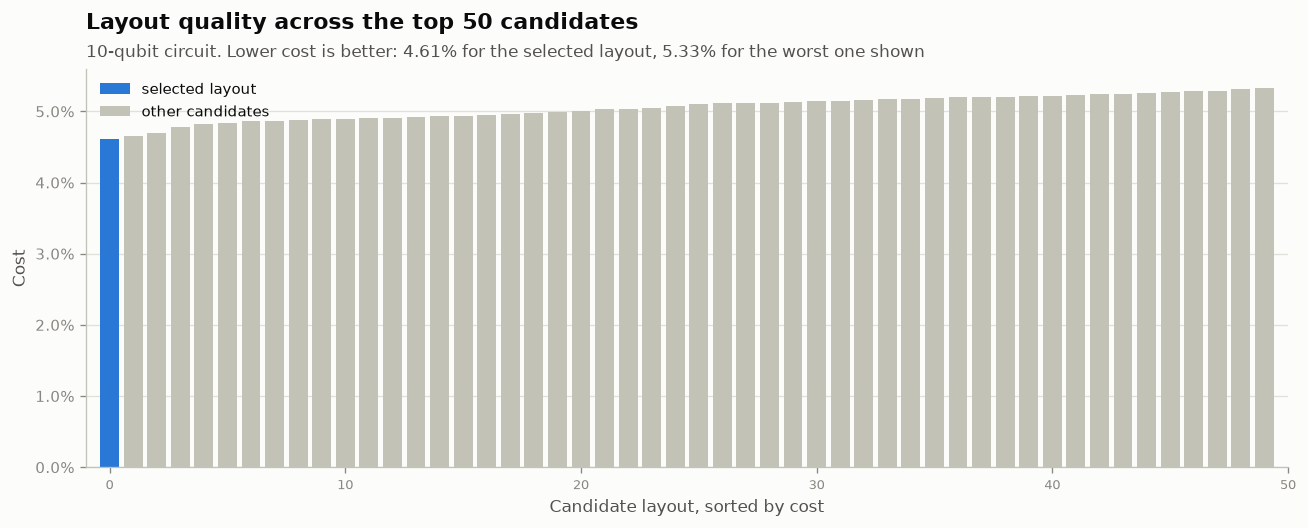

In [6]:
## How much does the choice actually matter? Look at the spread over the candidates.
ax = plot_cost_spread(cost, nqubits)

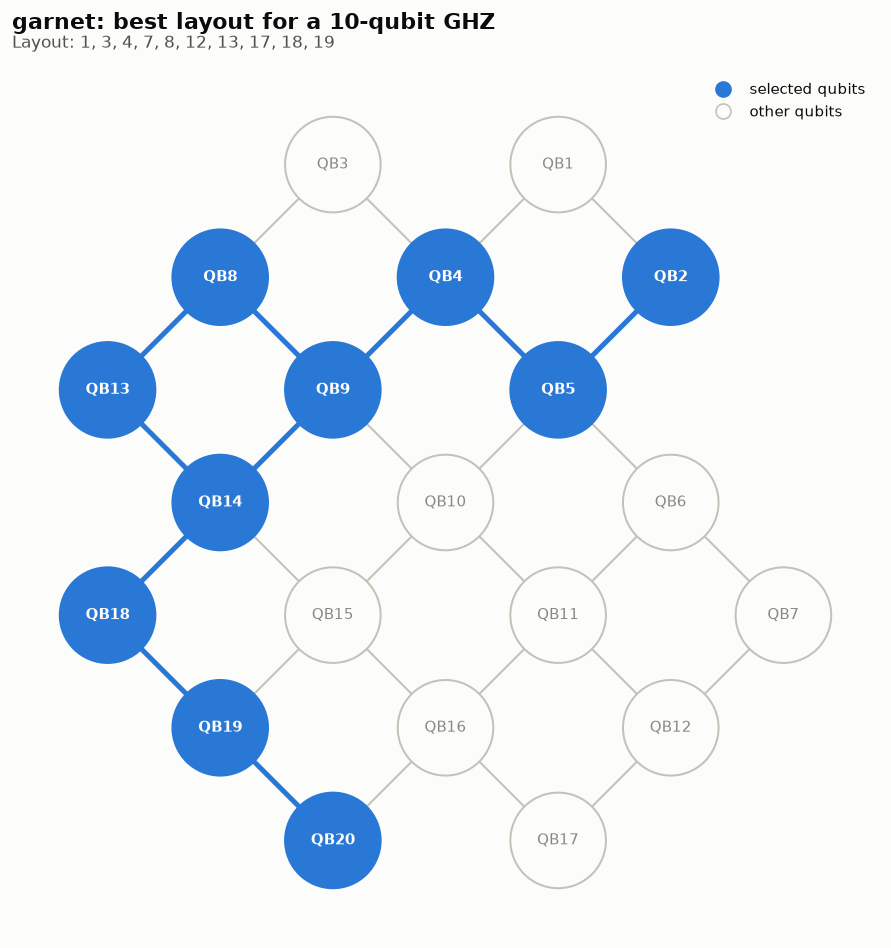

In [7]:
## Where do the selected qubits actually sit on the chip?
ax = plot_qpu_layout(backend, layouts[0], title=f"{quantum_computer}: best layout for a {nqubits}-qubit GHZ")

## 4. Finding the list of matching layouts

``LayoutGenerator`` gives you the full list of layouts compatible with the quantum circuit, without scoring
them. This is useful if you want to inspect the candidates, filter them yourself, or reuse the same list
across several cost functions (as done in the next section).

In [8]:
## Kept under its own name so that `layouts` still holds the cost-sorted layouts from the previous section.
all_layouts = LayoutGenerator(backend, qc_algo).generate_unique_layouts()

print(f"Found {len(all_layouts)} unique layouts for the {nqubits}-qubit circuit.")
print(f"First five: {all_layouts[:5]}")

Found 447 unique layouts for the 10-qubit circuit.
First five: [[3, 4, 5, 6, 8, 9, 10, 11, 15, 16], [3, 4, 7, 8, 9, 10, 12, 13, 14, 15], [3, 4, 8, 9, 10, 13, 14, 15, 17, 18], [3, 4, 8, 9, 10, 13, 14, 15, 18, 19], [3, 4, 8, 9, 10, 13, 15, 17, 18, 19]]


## 5. Tuning the cost function

### Adding readout fidelity to the cost function

Users can add the readout error to the cost function with the ``readoutmode`` argument of ``CostEvaluator``.

``ReadoutMode.FIDELITY`` adds the readout fidelity metric to the cost function, while ``ReadoutMode.QNDNESS``
adds the readout QNDness metric. This comes in handy when you are not performing readout error mitigation on
the target circuits. You can also ignore the readout error by omitting the argument or setting it to
``ReadoutMode.NONE``, which is the default.

In [9]:
layouts_with_readout, cost_with_readout = CostEvaluator(
    backend, qc_algo, readoutmode=ReadoutMode.QNDNESS
).get_top_layouts(num_layouts=10)

print(f"Best layout with QNDness in the cost: {layouts_with_readout[0]}, cost {cost_with_readout[0] * 100:.2f}%")

Best layout with QNDness in the cost: [1, 2, 3, 4, 7, 12, 13, 17, 18, 19], cost 20.94%


### Changing the two-qubit gate fidelity used in the cost function

The ``cost_function`` argument of ``CostEvaluator`` selects which two-qubit gate fidelity is used for the
evaluation.

By default the cost function uses the CZ gate fidelity (``CostFunction.GATE_COST_CZ``). You can use the
Clifford gate fidelity instead by setting ``cost_function=CostFunction.GATE_COST_CLIFFORD``. Passing the
``all_layouts`` list computed above avoids regenerating the candidate layouts.

In [10]:
clifford_layouts, cost_clifford = CostEvaluator(
    backend,
    qc_algo,
    cost_function=CostFunction.GATE_COST_CLIFFORD,
    layouts=all_layouts,
    readoutmode=ReadoutMode.NONE,
).get_top_layouts(num_layouts=10)

print(f"Best layout with Clifford fidelity: {clifford_layouts[0]}, cost {cost_clifford[0] * 100:.2f}%")

Best layout with Clifford fidelity: [1, 3, 4, 8, 10, 13, 15, 17, 18, 19], cost 9.41%


### Increasing the number of proposed layouts

To widen the search, increase the ``num_trials`` argument. It currently defaults to ``2000``.

This increases the run time of the cost function evaluation, but offers a better search across the possible
layouts.

In [11]:
more_layouts, cost_more = CostEvaluator(
    backend, qc_algo, num_trials=20000, readoutmode=ReadoutMode.NONE
).get_top_layouts(num_layouts=10)

print(f"Best layout after a wider search: {more_layouts[0]}, cost {cost_more[0] * 100:.2f}%")

Best layout after a wider search: [1, 3, 4, 7, 8, 12, 13, 17, 18, 19], cost 4.61%


### Removing qubits from consideration

Specific qubits can be excluded before the layouts are generated, so they never appear in any candidate.
This is handy when you know a qubit is behaving badly, or when it is reserved for something else.

In [12]:
qubits_to_remove = ["QB1", "QB2"]  ## plug in the qubits you want to remove from consideration
qubits_to_remove_qiskit_indices = [backend.qubit_name_to_index(qubit) for qubit in qubits_to_remove]

layouts_with_removed_qubits, cost_with_removed_qubits = CostEvaluator(
    backend, qc_algo, remove_qubits=qubits_to_remove_qiskit_indices
).get_top_layouts(num_layouts=10)

print(f"Best layout without {qubits_to_remove}: {layouts_with_removed_qubits[0]}, ")
print(f"cost {cost_with_removed_qubits[0] * 100:.2f}%")

Best layout without ['QB1', 'QB2']: [3, 7, 8, 12, 13, 15, 16, 17, 18, 19], 
cost 4.83%


## Recap

- Qubit quality varies across the chip and drifts between calibrations, so the choice of physical qubits
  directly affects the quality of the result.
- ``CostEvaluator(backend, circuit).get_top_layouts()`` is the single call that turns the latest calibration
  data into a ranked list of layouts. Lower cost is better.
- The cost function is configurable: ``readoutmode`` for readout fidelity or QNDness, ``cost_function`` for
  CZ vs. Clifford two-qubit fidelity, ``num_trials`` for a wider search, and ``remove_qubits`` to exclude
  qubits entirely.
- Transpile onto the chosen layout with ``perform_backend_transpilation`` and the reduced coupling map, so
  that the selection survives transpilation.
- Drawing the layout on the chip shows the selection is a compact, well calibrated patch rather than an
  arbitrary set of qubits.
- On hardware, the selected layout gives a measurably higher GHZ Hellinger fidelity than the naive one.